In [3]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

%matplotlib inline

In [4]:
def load_dblp_csv(path):
    chunks = []
    for chunk in pd.read_csv(
        path,
        usecols=['abstract', 'authors', 'n_citation', 'references', 'title', 'venue', 'year', 'id'],
        chunksize=50000,
        engine='python'
    ):
        chunks.append(chunk)
    return pd.concat(chunks, ignore_index=True)

df = load_dblp_csv('dblp-v10.csv')
df.head()

,abstract,authors,n_citation,references,title,venue,year,id
0,"In this paper, a robust 3D triangular mesh wat...","['S. Ben Jabra', 'Ezzeddine Zagrouba']",50,"['09cb2d7d-47d1-4a85-bfe5-faa8221e644b', '10aa...",A new approach of 3D watermarking based on ima...,international symposium on computers and commu...,2008,4ab3735c-80f1-472d-b953-fa0557fed28b
1,We studied an autoassociative neural network w...,"['Joaquín J. Torres', 'Jesús M. Cortés', 'Joaq...",50,"['4017c9d2-9845-4ad2-ad5b-ba65523727c5', 'b118...",Attractor neural networks with activity-depend...,Neurocomputing,2007,4ab39729-af77-46f7-a662-16984fb9c1db
2,It is well-known that Sturmian sequences are t...,"['Genevi eve Paquin', 'Laurent Vuillon']",50,"['1c655ee2-067d-4bc4-b8cc-bc779e9a7f10', '2e4e...",A characterization of balanced episturmian seq...,Electronic Journal of Combinatorics,2007,4ab3a4cf-1d96-4ce5-ab6f-b3e19fc260de
3,One of the fundamental challenges of recognizi...,"['Yaser Sheikh', 'Mumtaz Sheikh', 'Mubarak Shah']",221,"['056116c1-9e7a-4f9b-a918-44eb199e67d6', '05ac...",Exploring the space of a human action,international conference on computer vision,2005,4ab3a98c-3620-47ec-b578-884ecf4a6206
4,This paper generalizes previous optimal upper ...,"['Efraim Laksman', 'Håkan Lennerstad', 'Magnus...",0,"['01a765b8-0cb3-495c-996f-29c36756b435', '5dbc...",Generalized upper bounds on the minimum distan...,Ima Journal of Mathematical Control and Inform...,2015,4ab3b585-82b4-4207-91dd-b6bce7e27c4e


**DBLP Citation Count Vs Publication Year**

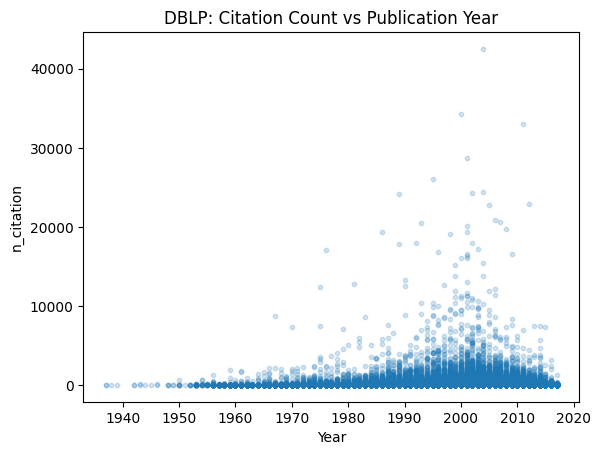

In [5]:
df_sample = df.drop_duplicates().copy()
df_sample['year'] = pd.to_numeric(df_sample['year'], errors='coerce')
df_sample['n_citation'] = pd.to_numeric(df_sample['n_citation'], errors='coerce')
df_sample = df_sample.dropna(subset=['year', 'n_citation']).copy()
plt.scatter(df_sample['year'], df_sample['n_citation'], alpha=0.2, s=10)
plt.xlabel('Year')
plt.ylabel('n_citation')
plt.title('DBLP: Citation Count vs Publication Year')
plt.show()

<p style='color:purple'><b>The approach we are going to use here is to split available data in two sets</b></p>
<ol>
<b>
<li>Training: We will train our model on this dataset</li>
<li>Testing: We will use this subset to make actual predictions using trained model</li>
</b>
</ol>
<p style='color:purple'><b>The reason we don't use same training set for testing is because our model has seen those samples before, using same samples for making predictions might give us wrong impression about accuracy of our model.</b></p>

In [6]:
def count_items(value):
    if pd.isna(value):
        return 0

    text = str(value).strip()
    if text in ('', '[]', 'nan', 'None'):
        return 0

    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, (list, tuple, set, dict)):
            return len(parsed)
    except (ValueError, SyntaxError):
        pass

    cleaned = text.strip('[]')
    if not cleaned:
        return 0

    return len([item for item in cleaned.split(',') if item.strip()])

clean_df = df.drop_duplicates().copy()
text_columns = ['abstract', 'authors', 'references', 'title', 'venue']
clean_df[text_columns] = clean_df[text_columns].fillna('')
clean_df['year'] = pd.to_numeric(clean_df['year'], errors='coerce')
clean_df['n_citation'] = pd.to_numeric(clean_df['n_citation'], errors='coerce')
clean_df = clean_df.dropna(subset=['year', 'n_citation']).copy()
clean_df['year'] = clean_df['year'].astype(int)
clean_df['reference_count'] = clean_df['references'].apply(count_items)
clean_df['author_count'] = clean_df['authors'].apply(count_items)
clean_df['title_length'] = clean_df['title'].str.len()
clean_df['abstract_length'] = clean_df['abstract'].str.len()
clean_df['venue_length'] = clean_df['venue'].str.len()
clean_df['high_impact'] = (clean_df['n_citation'] > clean_df['n_citation'].median()).astype(int)

print('Cleaned rows:', len(clean_df))
print('Duplicate rows:', clean_df.duplicated().sum())
print('Missing values per column:')
print(clean_df.isna().sum())

assert clean_df.isna().sum().sum() == 0
assert clean_df.duplicated().sum() == 0

clean_df.head()

Cleaned rows: 1000000
Duplicate rows: 0
Missing values per column:
abstract           0
authors            0
n_citation         0
references         0
title              0
venue              0
year               0
id                 0
reference_count    0
author_count       0
title_length       0
abstract_length    0
venue_length       0
high_impact        0
dtype: int64


,abstract,authors,n_citation,references,title,venue,year,id,reference_count,author_count,title_length,abstract_length,venue_length,high_impact
0,"In this paper, a robust 3D triangular mesh wat...","['S. Ben Jabra', 'Ezzeddine Zagrouba']",50,"['09cb2d7d-47d1-4a85-bfe5-faa8221e644b', '10aa...",A new approach of 3D watermarking based on ima...,international symposium on computers and commu...,2008,4ab3735c-80f1-472d-b953-fa0557fed28b,7,2,61,511,55,1
1,We studied an autoassociative neural network w...,"['Joaquín J. Torres', 'Jesús M. Cortés', 'Joaq...",50,"['4017c9d2-9845-4ad2-ad5b-ba65523727c5', 'b118...",Attractor neural networks with activity-depend...,Neurocomputing,2007,4ab39729-af77-46f7-a662-16984fb9c1db,3,4,93,1021,14,1
2,It is well-known that Sturmian sequences are t...,"['Genevi eve Paquin', 'Laurent Vuillon']",50,"['1c655ee2-067d-4bc4-b8cc-bc779e9a7f10', '2e4e...",A characterization of balanced episturmian seq...,Electronic Journal of Combinatorics,2007,4ab3a4cf-1d96-4ce5-ab6f-b3e19fc260de,7,2,52,711,35,1
3,One of the fundamental challenges of recognizi...,"['Yaser Sheikh', 'Mumtaz Sheikh', 'Mubarak Shah']",221,"['056116c1-9e7a-4f9b-a918-44eb199e67d6', '05ac...",Exploring the space of a human action,international conference on computer vision,2005,4ab3a98c-3620-47ec-b578-884ecf4a6206,10,3,37,1019,43,1
4,This paper generalizes previous optimal upper ...,"['Efraim Laksman', 'Håkan Lennerstad', 'Magnus...",0,"['01a765b8-0cb3-495c-996f-29c36756b435', '5dbc...",Generalized upper bounds on the minimum distan...,Ima Journal of Mathematical Control and Inform...,2015,4ab3b585-82b4-4207-91dd-b6bce7e27c4e,9,3,67,201,51,0


**Looking at the plot and the cleaned data, we will use logistic regression because the target is binary: papers with citations above the median versus papers below the median.**

In [7]:
X = clean_df[['year', 'reference_count', 'author_count', 'title_length', 'abstract_length', 'venue_length']]
y = clean_df['high_impact']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10, stratify=y)

In [9]:
X_train

,year,reference_count,author_count,title_length,abstract_length,venue_length
824794,2016,11,5,69,707,17
272780,1993,5,3,65,1013,49
499178,2012,16,2,91,1374,8
395795,2011,2,2,87,845,59
805365,2012,0,6,36,0,46
...,...,...,...,...,...,...
823587,2006,0,3,66,1017,33
49065,2002,9,3,68,758,0
798848,2016,21,2,51,2123,37
188399,2008,2,2,47,1174,28


In [10]:
X_test

,year,reference_count,author_count,title_length,abstract_length,venue_length
920313,2016,2,3,51,1194,48
137836,2007,0,4,56,1023,22
709276,2016,8,3,70,828,48
841433,2016,5,4,67,896,0
454813,2009,14,7,64,415,39
...,...,...,...,...,...,...
616353,2015,31,26,28,1111,0
190096,2001,4,2,102,871,32
539257,2011,4,2,53,611,28
505559,2008,26,1,37,342,28


In [11]:
y_train

824794    0
272780    1
499178    1
395795    0
805365    0
         ..
823587    0
49065     1
798848    0
188399    1
368482    0
Name: high_impact, Length: 700000, dtype: int32

In [12]:
y_test

920313    0
137836    1
709276    1
841433    1
454813    1
         ..
616353    0
190096    1
539257    1
505559    1
15108     0
Name: high_impact, Length: 300000, dtype: int32

**Lets run logistic regression model now**

In [13]:
clf = LogisticRegression(max_iter=2000, C=0.1)
clf.fit(X_train, y_train)

LogisticRegression(C=0.1, max_iter=2000)

In [14]:
X_test

,year,reference_count,author_count,title_length,abstract_length,venue_length
920313,2016,2,3,51,1194,48
137836,2007,0,4,56,1023,22
709276,2016,8,3,70,828,48
841433,2016,5,4,67,896,0
454813,2009,14,7,64,415,39
...,...,...,...,...,...,...
616353,2015,31,26,28,1111,0
190096,2001,4,2,102,871,32
539257,2011,4,2,53,611,28
505559,2008,26,1,37,342,28


In [15]:
clf.predict(X_test)

array([0, 1, 0, ..., 0, 1, 1])

In [16]:
y_test

920313    0
137836    1
709276    1
841433    1
454813    1
         ..
616353    0
190096    1
539257    1
505559    1
15108     0
Name: high_impact, Length: 300000, dtype: int32

In [17]:
y_prob = clf.predict_proba(X_test)[:, 1]
best_threshold = 0.195
y_pred_tuned = (y_prob >= best_threshold).astype(int)

print('Default accuracy:', clf.score(X_test, y_test))
print('Tuned accuracy:', accuracy_score(y_test, y_pred_tuned))
print('Best threshold:', best_threshold)
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred_tuned))
print('Classification report:')
print(classification_report(y_test, y_pred_tuned))

Default accuracy: 0.71844
Tuned accuracy: 0.5738533333333333
Best threshold: 0.195
Confusion matrix:
[[ 27702 124147]
 [  3697 144454]]
Classification report:
              precision    recall  f1-score   support

           0       0.88      0.18      0.30    151849
           1       0.54      0.98      0.69    148151

    accuracy                           0.57    300000
   macro avg       0.71      0.58      0.50    300000
weighted avg       0.71      0.57      0.50    300000



**random_state argument**

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10, stratify=y)
X_test

,year,reference_count,author_count,title_length,abstract_length,venue_length
920313,2016,2,3,51,1194,48
137836,2007,0,4,56,1023,22
709276,2016,8,3,70,828,48
841433,2016,5,4,67,896,0
454813,2009,14,7,64,415,39
...,...,...,...,...,...,...
616353,2015,31,26,28,1111,0
190096,2001,4,2,102,871,32
539257,2011,4,2,53,611,28
505559,2008,26,1,37,342,28


In [19]:
clf = LogisticRegression(max_iter=2000, C=0.1)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.71844